In [0]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
# Import 
delta_global = "/Volumes/workspace/weather/data/continents2_06_03/"  
df_with_country= spark.read.format("delta").load(delta_global)
df=df_with_country

Statistiche per città/anno (anteprima):


year,continent,country,NAME,avg_temp_c,max_temp_c,min_temp_c,giorni_prcp_gt_10mm,giorni_prcp_lt_4mm
2000,AF,Egitto,"ASWAN INTERNATIONAL, EG",26.280060882800583,48.111111111111114,5.0,0,365
2000,AF,Egitto,"BAHARIA, EG",20.790809327846375,41.611111111111114,2.2222222222222223,1,242
2000,AF,Kenya,"NAIROBI JKIA, KE",19.356902356902346,31.77777777777778,6.611111111111111,20,343
2000,AF,Kenya,"ELDORET, KE",16.918855218855224,29.0,4.000000000000002,105,225
2000,AF,Marocco,"OUARZAZATE, MO",19.836824529447483,40.611111111111114,-2.6111111111111107,0,366
2000,AF,Marocco,"ANFA, MO",18.309046751669705,39.0,3.888888888888889,5,361
2000,AF,Marocco,"ESSAOUIRA, MO",16.88857852265674,36.0,7.6111111111111125,3,355
2000,AF,Nigeria,"YOLA, NI",30.77777777777778,37.5,19.0,0,1
2000,AF,Nigeria,"MALLAM AMINU INTERNATIONAL, NI",22.022222222222222,32.0,14.000000000000002,0,5
2000,AF,Sudafrica,"CAPE TOWN INTERNATIONAL, SF",17.003957382039573,41.27777777777778,-4.611111111111111,7,358


Top 10 città per temperatura media (per ogni anno):


year,continent,country,NAME,avg_temp_c,rank_hot
2000,AF,Nigeria,"YOLA, NI",30.77777777777778,1
2000,AS,Indonesia,"JAKARTA TANJUNG PRIOK, ID",28.416666666666668,2
2000,AS,India,"CHENNAI INTERNATIONAL, IN",28.317091681845767,3
2000,NA,Giamaica,"NORMAN MANLEY INTERNATIONAL, JM",27.95022831050231,4
2000,NA,El Salvador,"EL SALVADOR INTERNATIONAL, ES",27.652187598363266,5
2000,AS,Indonesia,"SOEKARNO HATTA INTERNATIONAL, ID",27.39435336976319,6
2000,SA,Brasile,"PONTA PELADA, BR",27.28344046525865,7
2000,AS,Indonesia,"HASANUDDIN, ID",26.850789313904052,8
2000,NA,Messico,"LICENCIADO MANUEL CRESCENCIO REJON INT, MX",26.353120243531226,9
2000,AF,Egitto,"ASWAN INTERNATIONAL, EG",26.280060882800583,10


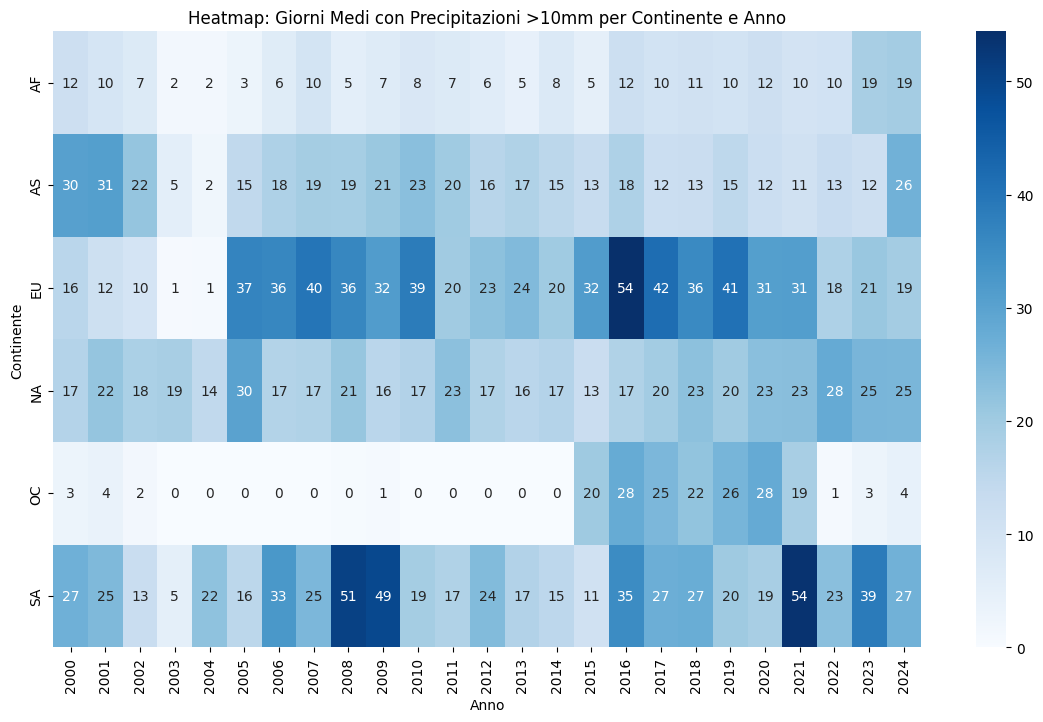

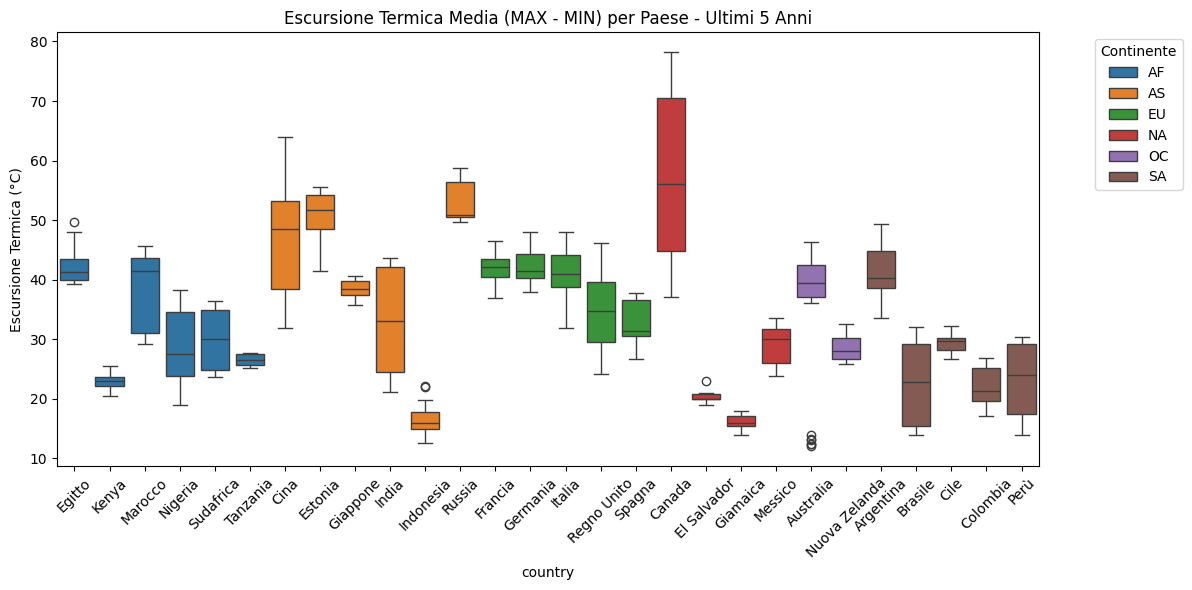

In [0]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

# =============================================================================
# 1. Aggregazione per città/anno con country
# =============================================================================

# Assumi df_all sia il DataFrame unito con colonne: TEMP_c, MAX_c, MIN_c, PRCP, continent, NAME, country, year
df = df_with_country.filter(F.col("TEMP_c").isNotNull())

stats_per_year = df.groupBy("year", "continent", "country", "NAME") \
    .agg(
        F.avg("TEMP_c").alias("avg_temp_c"),
        F.max("MAX_c").alias("max_temp_c"),
        F.min("MIN_c").alias("min_temp_c"),
        F.count(F.when(F.col("PRCP") > 10, True)).alias("giorni_prcp_gt_10mm"),
        F.count(F.when(F.col("PRCP") < 4, True)).alias("giorni_prcp_lt_4mm")
    ) \
    .filter(F.col("avg_temp_c").isNotNull()) \
    .orderBy("year", "continent", "country", F.desc("avg_temp_c"))

print("Statistiche per città/anno (anteprima):")
display(stats_per_year.limit(20))

# =============================================================================
# 2. TOP10 città per temperatura media (per ogni anno) - con country
# =============================================================================

window_temp = Window.partitionBy("year").orderBy(F.desc("avg_temp_c"))

top10_hot = stats_per_year.withColumn(
    "rank_hot", F.row_number().over(window_temp)
).filter(F.col("rank_hot") <= 10) \
 .select("year", "continent", "country", "NAME", "avg_temp_c", "rank_hot") \
 .orderBy("year", "rank_hot")

print("Top 10 città per temperatura media (per ogni anno):")
display(top10_hot)

# =============================================================================
# 3. Visualizzazioni con Plotly (interattivo) e Seaborn (statico)
# =============================================================================

# Converti in Pandas (dataset aggregato piccolo → veloce)
pdf_top10 = top10_hot.toPandas()
pdf_stats = stats_per_year.toPandas()

# --- Plotly: Line chart trend temperatura media per paese (top paesi selezionati) ---
fig_trend = px.line(
    pdf_stats[pdf_stats["country"].isin(pdf_top10["country"].unique()[:10])],  # top 10 paesi
    x="year",
    y="avg_temp_c",
    color="country",
    line_group="NAME",
    markers=True,
    title="Trend Temperatura Media Annuale - Top Paesi (con breakdown città)",
    labels={"avg_temp_c": "Temperatura Media (°C)", "year": "Anno"}
)
fig_trend.update_layout(
    hovermode="x unified",
    legend_title="Paese / Città",
    height=600
)
fig_trend.show()

# --- Plotly: Bar chart top10 città più calde ultimo anno disponibile ---
last_year = pdf_top10["year"].max()
pdf_last = pdf_top10[pdf_top10["year"] == last_year]

fig_bar = px.bar(
    pdf_last,
    x="NAME",
    y="avg_temp_c",
    color="country",
    text="rank_hot",
    title=f"Top 10 Città Più Calde nell'Anno {last_year}",
    labels={"avg_temp_c": "Temperatura Media (°C)", "NAME": "Città"}
)
fig_bar.update_traces(textposition="outside")
fig_bar.update_layout(xaxis_tickangle=-45, height=600)
fig_bar.show()

# --- Seaborn: Heatmap giorni pioggia >10mm per continente/anno ---
pivot_rain = pdf_stats.pivot_table(
    index="continent",
    columns="year",
    values="giorni_prcp_gt_10mm",
    aggfunc="mean"
)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_rain, annot=True, cmap="Blues", fmt=".0f")
plt.title("Heatmap: Giorni Medi con Precipitazioni >10mm per Continente e Anno")
plt.xlabel("Anno")
plt.ylabel("Continente")
plt.show()

# --- Seaborn: Boxplot escursione termica per paese (ultimi 5 anni) ---
pdf_box = pdf_stats[pdf_stats["year"] >= pdf_stats["year"].max() - 5].copy()
pdf_box["escursione"] = pdf_box["max_temp_c"] - pdf_box["min_temp_c"]

plt.figure(figsize=(12, 6))
sns.boxplot(data=pdf_box, x="country", y="escursione", hue="continent")
plt.title("Escursione Termica Media (MAX - MIN) per Paese - Ultimi 5 Anni")
plt.xticks(rotation=45)
plt.ylabel("Escursione Termica (°C)")
plt.legend(title="Continente", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [0]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

# =============================================================================
# PREPARAZIONE: Filtra anni 2014-2024 e aggregazioni base con country
# =============================================================================

# Assumi df_all già caricato con colonne: TEMP_c, MAX_c, MIN_c, PRCP, DEWP, FRSHTT, WDSP, GUST, continent, country, NAME, year
# Filtra anni 2014-2024
df = df.filter(F.col("year").between(2014, 2024) & F.col("TEMP_c").isNotNull())

# Aggregazione base per città/anno con country
stats_city_year = df.groupBy("year", "continent", "country", "NAME") \
    .agg(
        F.avg("TEMP_c").alias("avg_temp_c"),
        F.max("MAX_c").alias("max_temp_c"),
        F.min("MIN_c").alias("min_temp_c"),
        F.count(F.when(F.col("PRCP") > 10, True)).alias("giorni_prcp_gt_10mm"),
        F.count(F.when(F.col("PRCP") < 4, True)).alias("giorni_prcp_lt_4mm"),
        F.count(F.when(F.col("MIN_c") < 0, True)).alias("giorni_gelo_lt_0c"),
        F.count(F.when(F.col("MAX_c") > 35, True)).alias("giorni_caldo_gt_35c"),
        F.stddev("TEMP_c").alias("variabilita_temp_c"),
        F.avg(F.when(F.col("TEMP_c") != 0, (F.col("DEWP") / F.col("TEMP_c")) * 100)).alias("avg_umidita_pct"),
        F.count(F.when(F.substring("FRSHTT", 5, 1) == "1", True)).alias("giorni_fulmini"),
        F.count(F.when(F.substring("FRSHTT", 3, 1) == "1", True)).alias("giorni_neve"),
        F.count(F.when(F.substring("FRSHTT", 4, 1) == "1", True)).alias("giorni_grandine"),
        F.avg(F.col("MAX_c") - F.col("MIN_c")).alias("avg_escursione_temp_c"),
        F.avg("WDSP").alias("avg_wind_knots")
    ).filter(F.col("avg_temp_c").isNotNull())

# Baseline per anomalie (2014-2018 come baseline recente, dato il filtro anni)
baseline = stats_city_year.filter(F.col("year").between(2014, 2018)) \
    .groupBy("continent", "country", "NAME") \
    .agg(F.avg("avg_temp_c").alias("baseline_avg_temp_c"))

# Aggiungi anomalie
stats_city_year = stats_city_year.join(
    baseline, ["continent", "country", "NAME"], "left"
).withColumn(
    "anomalia_temp_c", F.col("avg_temp_c") - F.col("baseline_avg_temp_c")
)

# Aggregazione per continente/anno con country
stats_continent_year = stats_city_year.groupBy("continent", "year") \
    .agg(
        F.avg("avg_temp_c").alias("avg_temp_c"),
        F.avg("variabilita_temp_c").alias("variabilita_temp_c"),
        F.avg("avg_umidita_pct").alias("avg_umidita_pct"),
        F.avg("giorni_prcp_gt_10mm").alias("avg_giorni_prcp_gt_10mm"),
        F.avg("giorni_caldo_gt_35c").alias("avg_giorni_caldo_gt_35c"),
        F.avg("giorni_gelo_lt_0c").alias("avg_giorni_gelo_lt_0c"),
        F.avg("giorni_fulmini").alias("avg_giorni_fulmini"),
        F.avg("avg_escursione_temp_c").alias("avg_escursione_temp_c"),
        F.avg("avg_wind_knots").alias("avg_wind_knots")
    )

# Aggregazione per country/anno
stats_country_year = stats_city_year.groupBy("continent", "country", "year") \
    .agg(
        F.avg("avg_temp_c").alias("avg_temp_c"),
        F.avg("variabilita_temp_c").alias("variabilita_temp_c"),
        F.avg("avg_umidita_pct").alias("avg_umidita_pct"),
        F.avg("giorni_prcp_gt_10mm").alias("avg_giorni_prcp_gt_10mm"),
        F.avg("giorni_caldo_gt_35c").alias("avg_giorni_caldo_gt_35c"),
        F.avg("giorni_gelo_lt_0c").alias("avg_giorni_gelo_lt_0c"),
        F.avg("giorni_fulmini").alias("avg_giorni_fulmini"),
        F.avg("avg_escursione_temp_c").alias("avg_escursione_temp_c"),
        F.avg("avg_wind_knots").alias("avg_wind_knots")
    )


In [0]:

# =============================================================================
# TOP6 CONTINENTI PER ANNO (per media temp, variabilità, umidità, ecc.)
# =============================================================================

# Top6 continenti per media temp per anno
window_cont_temp = Window.partitionBy("year").orderBy(F.desc("avg_temp_c"))
top6_cont_temp = stats_continent_year.withColumn(
    "rank_temp", F.row_number().over(window_cont_temp)
).filter(F.col("rank_temp") <= 6) \
 .orderBy("year", "rank_temp")

print("Top6 continenti per media temp per anno:")
display(top6_cont_temp)

# Top6 per variabilità temp per anno
window_cont_var = Window.partitionBy("year").orderBy(F.desc("variabilita_temp_c"))
top6_cont_var = stats_continent_year.withColumn(
    "rank_var", F.row_number().over(window_cont_var)
).filter(F.col("rank_var") <= 6) \
 .orderBy("year", "rank_var")

print("Top6 continenti per variabilità temp per anno:")
display(top6_cont_var)

# Ripeti per altre (es. umidità)
window_cont_hum = Window.partitionBy("year").orderBy(F.desc("avg_umidita_pct"))
top6_cont_hum = stats_continent_year.withColumn(
    "rank_hum", F.row_number().over(window_cont_hum)
).filter(F.col("rank_hum") <= 6) \
 .orderBy("year", "rank_hum")

print("Top6 continenti per umidità media per anno:")
display(top6_cont_hum)

# =============================================================================
# TOP10 COUNTRY PER ANNO (per media temp, variabilità, umidità, ecc.)
# =============================================================================

# Top10 country per media temp per anno
window_country_temp = Window.partitionBy("year").orderBy(F.desc("avg_temp_c"))
top10_country_temp = stats_country_year.withColumn(
    "rank_temp", F.row_number().over(window_country_temp)
).filter(F.col("rank_temp") <= 10) \
 .orderBy("year", "rank_temp")

print("Top10 country per media temp per anno:")
display(top10_country_temp)

# Top10 per variabilità temp per anno
window_country_var = Window.partitionBy("year").orderBy(F.desc("variabilita_temp_c"))
top10_country_var = stats_country_year.withColumn(
    "rank_var", F.row_number().over(window_country_var)
).filter(F.col("rank_var") <= 10) \
 .orderBy("year", "rank_var")

print("Top10 country per variabilità temp per anno:")
display(top10_country_var)

# Ripeti per altre (es. umidità)
window_country_hum = Window.partitionBy("year").orderBy(F.desc("avg_umidita_pct"))
top10_country_hum = stats_country_year.withColumn(
    "rank_hum", F.row_number().over(window_country_hum)
).filter(F.col("rank_hum") <= 10) \
 .orderBy("year", "rank_hum")

print("Top10 country per umidità media per anno:")
display(top10_country_hum)



Top6 continenti per media temp per anno:


continent,year,avg_temp_c,variabilita_temp_c,avg_umidita_pct,avg_giorni_prcp_gt_10mm,avg_giorni_caldo_gt_35c,avg_giorni_gelo_lt_0c,avg_giorni_fulmini,avg_escursione_temp_c,avg_wind_knots,rank_temp
AF,2014,21.015186067804443,4.3010615484235055,382.0186376076819,7.818181818181818,53.36363636363637,7.636363636363637,0.45454545454545453,11.79363266012337,7.186277916483877,1
AS,2014,20.245625825052233,6.159911824485978,2410.0525518533013,15.461538461538462,39.76923076923077,32.0,2.230769230769231,9.223450743115967,5.455885250116443,2
SA,2014,17.8784293877226,2.60568778972647,328.8564407506904,15.125,7.625,16.0,4.5,11.140795823193752,5.704545968495422,3
NA,2014,17.327293161487397,6.0574820251715185,299.78982171614285,16.714285714285715,3.7142857142857144,57.142857142857146,0.5714285714285714,9.134100598931301,9.151695133588024,4
OC,2014,16.905934755249824,4.023497380540812,326.28836523851527,0.0,10.0,2.7142857142857144,0.14285714285714285,10.019453085081977,9.868171629118077,5
EU,2014,14.021440575849823,5.2089784352342585,793.3248708458882,20.083333333333332,0.5833333333333334,12.5,0.8333333333333334,8.34022809910367,7.533971651445968,6
AF,2015,21.652025662933625,4.388337725554528,337.4398778108453,5.083333333333333,50.25,4.416666666666667,0.16666666666666666,11.787879484476456,7.647725941573605,1
AS,2015,20.32737147155627,5.72309747936355,840.3092360832063,13.23076923076923,37.38461538461539,26.076923076923077,1.3076923076923077,9.317875331063622,5.635119871622692,2
NA,2015,19.238299547864937,5.471414235982792,296.59783269740586,12.625,36.625,45.875,0.375,9.707946510945058,8.974798635058551,3
SA,2015,18.529579109653188,2.517931713311158,319.2292486074918,10.88888888888889,7.0,13.222222222222221,2.4444444444444446,10.646435968258281,6.098224257394862,4


Top6 continenti per variabilità temp per anno:


continent,year,avg_temp_c,variabilita_temp_c,avg_umidita_pct,avg_giorni_prcp_gt_10mm,avg_giorni_caldo_gt_35c,avg_giorni_gelo_lt_0c,avg_giorni_fulmini,avg_escursione_temp_c,avg_wind_knots,rank_var
AS,2014,20.245625825052233,6.159911824485978,2410.0525518533013,15.461538461538462,39.76923076923077,32.0,2.230769230769231,9.223450743115967,5.455885250116443,1
NA,2014,17.327293161487397,6.0574820251715185,299.78982171614285,16.714285714285715,3.7142857142857144,57.142857142857146,0.5714285714285714,9.134100598931301,9.151695133588024,2
EU,2014,14.021440575849823,5.2089784352342585,793.3248708458882,20.083333333333332,0.5833333333333334,12.5,0.8333333333333334,8.34022809910367,7.533971651445968,3
AF,2014,21.015186067804443,4.3010615484235055,382.0186376076819,7.818181818181818,53.36363636363637,7.636363636363637,0.45454545454545453,11.79363266012337,7.186277916483877,4
OC,2014,16.905934755249824,4.023497380540812,326.28836523851527,0.0,10.0,2.7142857142857144,0.14285714285714285,10.019453085081977,9.868171629118077,5
SA,2014,17.8784293877226,2.60568778972647,328.8564407506904,15.125,7.625,16.0,4.5,11.140795823193752,5.704545968495422,6
AS,2015,20.32737147155627,5.72309747936355,840.3092360832063,13.23076923076923,37.38461538461539,26.076923076923077,1.3076923076923077,9.317875331063622,5.635119871622692,1
EU,2015,13.756723336345331,5.59350575661108,540.6381893474386,31.666666666666668,3.25,21.25,0.4166666666666667,8.45828565945186,7.445423210414648,2
NA,2015,19.238299547864937,5.471414235982792,296.59783269740586,12.625,36.625,45.875,0.375,9.707946510945058,8.974798635058551,3
OC,2015,16.872286528473936,4.511781415339725,329.08103052659425,20.285714285714285,17.142857142857142,3.142857142857143,0.14285714285714285,9.969665378152202,9.662547950687125,4


Top6 continenti per umidità media per anno:


...

continent,country,year,avg_temp_c,variabilita_temp_c,avg_umidita_pct,avg_giorni_prcp_gt_10mm,avg_giorni_caldo_gt_35c,avg_giorni_gelo_lt_0c,avg_giorni_fulmini,avg_escursione_temp_c,avg_wind_knots,rank_temp
AF,Nigeria,2014,28.556078397199887,4.026256159338112,293.2624317277999,10.5,67.5,0.0,0.0,10.67505391804457,6.895109796745308,1
NA,Giamaica,2014,28.271385083713852,1.1920930055936405,259.79801873853194,0.0,1.0,0.0,0.0,7.426027397260275,10.373150684931513,2
AS,Indonesia,2014,28.04388285791356,1.1076737747999303,263.2863021856274,37.333333333333336,13.0,0.0,1.3333333333333333,8.37509060439737,4.415392027372103,3
NA,El Salvador,2014,27.57199391171994,1.1237379444558213,258.2781977756401,117.0,8.0,0.0,0.0,9.806849315068494,5.0383561643835595,4
NA,Messico,2014,26.149725274725263,3.2383429203949308,267.442853555454,0.0,14.0,0.0,2.0,10.365079365079364,4.940659340659344,5
AS,India,2014,26.061897513952307,4.631211765385515,259.6249127470474,8.0,135.33333333333334,0.0,0.3333333333333333,11.953170979198374,3.8042922374429238,6
AF,Egitto,2014,25.806376521935263,6.695739688833348,167.76994850027455,0.5,168.5,0.0,0.0,16.22753140043401,5.114621988259921,7
NA,Cuba,2014,25.178617571059434,2.408357178225461,274.6779502227143,0.0,3.0,0.0,1.0,8.462209302325574,19.906686046511638,8
SA,Brasile,2014,23.884233821733837,2.519439151151775,274.95379656943146,21.0,6.0,0.0,0.5,8.371336996336996,5.252197802197804,9
AF,Tanzania,2014,23.54986149584489,2.156332604143746,262.27994788096385,11.0,18.0,0.0,0.0,12.351800554016624,5.34404432132964,10


Top10 country per variabilità temp per anno:


continent,country,year,avg_temp_c,variabilita_temp_c,avg_umidita_pct,avg_giorni_prcp_gt_10mm,avg_giorni_caldo_gt_35c,avg_giorni_gelo_lt_0c,avg_giorni_fulmini,avg_escursione_temp_c,avg_wind_knots,rank_var
NA,Canada,2014,4.706443429731098,11.479947709176926,346.1105772402198,0.0,0.0,133.33333333333334,0.3333333333333333,9.292846270928466,7.934337899543373,1
AS,Russia,2014,7.1977124183006564,11.458703092196563,27732.880925500613,7.0,0.0,92.0,1.0,5.169389978213506,10.463071895424832,2
AS,Cina,2014,17.8089802130898,8.792916964043652,307.41885233527404,19.0,23.0,58.0,7.666666666666667,10.364485032978182,5.1572602739726,3
AS,Estonia,2014,6.813850837138505,8.739348572662678,427.0327834098834,0.0,0.0,134.0,0.0,8.778234398782338,7.375890410958911,4
AS,Giappone,2014,16.71864535768646,8.142697270385597,339.8896316892874,0.5,1.5,8.0,0.0,6.939497716894978,6.478356164383565,5
AF,Egitto,2014,25.806376521935263,6.695739688833348,167.76994850027455,0.5,168.5,0.0,0.0,16.22753140043401,5.114621988259921,6
EU,Germania,2014,10.93363774733637,6.476902904991101,447.7547271041317,213.0,0.0,32.0,2.0,7.739726027397261,8.137808219178082,7
EU,Italia,2014,16.643074581430735,6.086870216759597,429.19480331636447,9.333333333333334,2.0,14.333333333333334,0.6666666666666666,9.224454591577876,5.583378995433793,8
AF,Marocco,2014,19.74093604207241,5.815335807521027,243.72891482572413,2.5,46.0,0.5,0.0,10.992673782446515,4.530905458178186,9
EU,Francia,2014,13.7978373921867,5.34034349077364,1880.31327359494,0.0,0.3333333333333333,9.333333333333334,1.0,10.037573989514632,8.305384322678842,10


Top10 country per umidità media per anno:


continent,country,year,avg_temp_c,variabilita_temp_c,avg_umidita_pct,avg_giorni_prcp_gt_10mm,avg_giorni_caldo_gt_35c,avg_giorni_gelo_lt_0c,avg_giorni_fulmini,avg_escursione_temp_c,avg_wind_knots,rank_hum
AS,Russia,2014,7.1977124183006564,11.458703092196563,27732.880925500613,7.0,0.0,92.0,1.0,5.169389978213506,10.463071895424832,1
EU,Francia,2014,13.7978373921867,5.34034349077364,1880.31327359494,0.0,0.3333333333333333,9.333333333333334,1.0,10.037573989514632,8.305384322678842,2
AF,Sudafrica,2014,13.218434797679302,3.5586473217231873,747.5416901635257,9.666666666666666,1.6666666666666667,27.666666666666668,1.3333333333333333,9.829213501830077,11.159510931391376,3
EU,Regno Unito,2014,11.115423642820907,4.224551644812332,485.5130474199557,0.0,0.0,15.666666666666666,0.3333333333333333,6.901623541349572,8.700730593607306,4
EU,Germania,2014,10.93363774733637,6.476902904991101,447.7547271041317,213.0,0.0,32.0,2.0,7.739726027397261,8.137808219178082,5
EU,Italia,2014,16.643074581430735,6.086870216759597,429.19480331636447,9.333333333333334,2.0,14.333333333333334,0.6666666666666666,9.224454591577876,5.583378995433793,6
AS,Estonia,2014,6.813850837138505,8.739348572662678,427.0327834098834,0.0,0.0,134.0,0.0,8.778234398782338,7.375890410958911,7
OC,Nuova Zelanda,2014,11.981328435873893,3.471977858559556,412.97100154432513,0.0,0.0,8.0,0.0,8.104759718396084,7.594352617079886,8
SA,Argentina,2014,15.590563165905632,4.97385507293838,391.50966912210407,10.5,23.0,56.5,1.0,12.173287671232877,8.17027397260274,9
SA,Cile,2014,14.042985723153313,2.565473307944349,362.1320573046481,0.0,0.0,1.0,0.0,9.78460583488516,5.73854748603352,10


continent,year,avg_temp_c,variabilita_temp_c,avg_umidita_pct,avg_giorni_prcp_gt_10mm,avg_giorni_caldo_gt_35c,avg_giorni_gelo_lt_0c,avg_giorni_fulmini,avg_escursione_temp_c,avg_wind_knots,rank_temp
AF,2014,21.015186067804443,4.3010615484235055,382.0186376076819,7.818181818181818,53.36363636363637,7.636363636363637,0.45454545454545453,11.79363266012337,7.186277916483877,1
AS,2014,20.245625825052233,6.159911824485978,2410.0525518533013,15.461538461538462,39.76923076923077,32.0,2.230769230769231,9.223450743115967,5.455885250116443,2
SA,2014,17.8784293877226,2.60568778972647,328.8564407506904,15.125,7.625,16.0,4.5,11.140795823193752,5.704545968495422,3
NA,2014,17.327293161487397,6.0574820251715185,299.78982171614285,16.714285714285715,3.7142857142857144,57.142857142857146,0.5714285714285714,9.134100598931301,9.151695133588024,4
OC,2014,16.905934755249824,4.023497380540812,326.28836523851527,0.0,10.0,2.7142857142857144,0.14285714285714285,10.019453085081977,9.868171629118077,5
EU,2014,14.021440575849823,5.2089784352342585,793.3248708458882,20.083333333333332,0.5833333333333334,12.5,0.8333333333333334,8.34022809910367,7.533971651445968,6
AF,2015,21.652025662933625,4.388337725554528,337.4398778108453,5.083333333333333,50.25,4.416666666666667,0.16666666666666666,11.787879484476456,7.647725941573605,1
AS,2015,20.32737147155627,5.72309747936355,840.3092360832063,13.23076923076923,37.38461538461539,26.076923076923077,1.3076923076923077,9.317875331063622,5.635119871622692,2
NA,2015,19.238299547864937,5.471414235982792,296.59783269740586,12.625,36.625,45.875,0.375,9.707946510945058,8.974798635058551,3
SA,2015,18.529579109653188,2.517931713311158,319.2292486074918,10.88888888888889,7.0,13.222222222222221,2.4444444444444446,10.646435968258281,6.098224257394862,4


continent,country,year,avg_temp_c,variabilita_temp_c,avg_umidita_pct,avg_giorni_prcp_gt_10mm,avg_giorni_caldo_gt_35c,avg_giorni_gelo_lt_0c,avg_giorni_fulmini,avg_escursione_temp_c,avg_wind_knots,rank_temp
AF,Nigeria,2014,28.556078397199887,4.026256159338112,293.2624317277999,10.5,67.5,0.0,0.0,10.67505391804457,6.895109796745308,1
NA,Giamaica,2014,28.271385083713852,1.1920930055936405,259.79801873853194,0.0,1.0,0.0,0.0,7.426027397260275,10.373150684931513,2
AS,Indonesia,2014,28.04388285791356,1.1076737747999303,263.2863021856274,37.333333333333336,13.0,0.0,1.3333333333333333,8.37509060439737,4.415392027372103,3
NA,El Salvador,2014,27.57199391171994,1.1237379444558213,258.2781977756401,117.0,8.0,0.0,0.0,9.806849315068494,5.0383561643835595,4
NA,Messico,2014,26.149725274725263,3.2383429203949308,267.442853555454,0.0,14.0,0.0,2.0,10.365079365079364,4.940659340659344,5
AS,India,2014,26.061897513952307,4.631211765385515,259.6249127470474,8.0,135.33333333333334,0.0,0.3333333333333333,11.953170979198374,3.8042922374429238,6
AF,Egitto,2014,25.806376521935263,6.695739688833348,167.76994850027455,0.5,168.5,0.0,0.0,16.22753140043401,5.114621988259921,7
NA,Cuba,2014,25.178617571059434,2.408357178225461,274.6779502227143,0.0,3.0,0.0,1.0,8.462209302325574,19.906686046511638,8
SA,Brasile,2014,23.884233821733837,2.519439151151775,274.95379656943146,21.0,6.0,0.0,0.5,8.371336996336996,5.252197802197804,9
AF,Tanzania,2014,23.54986149584489,2.156332604143746,262.27994788096385,11.0,18.0,0.0,0.0,12.351800554016624,5.34404432132964,10


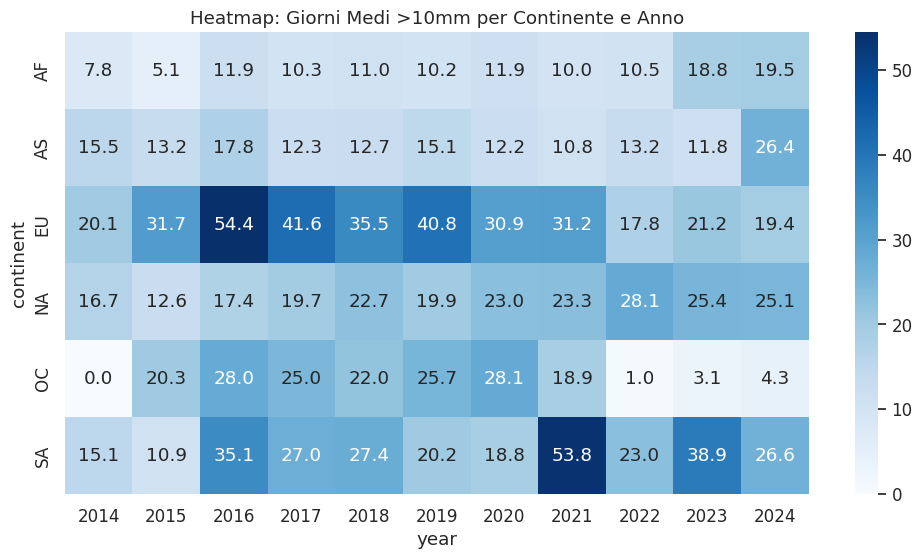

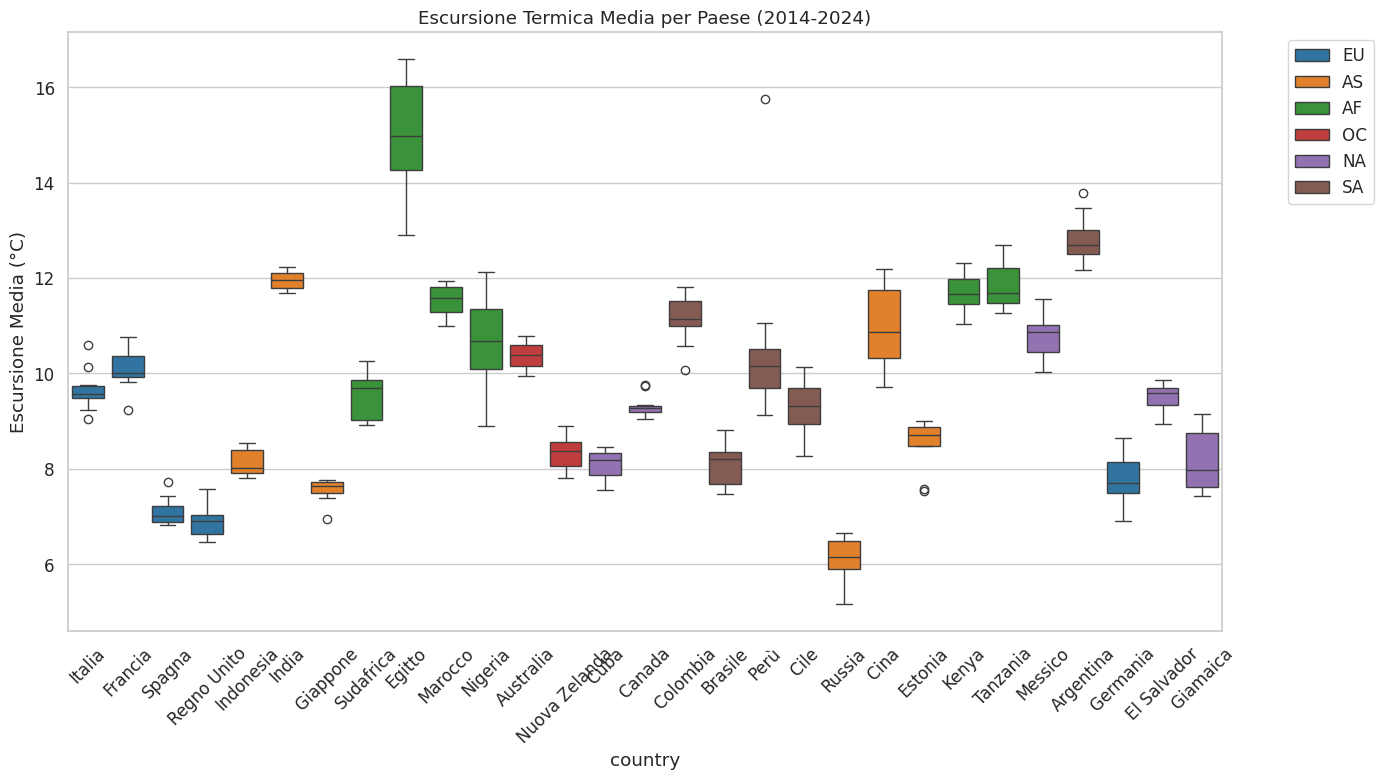

---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
File <command-4906186020937678>, line 148
    145 plt.show()
    147 # 5. Plotly - Anomalie temperatura per paese (line + size = giorni caldo)
--> 148 fig_anom = px.line(
    149     pdf_country,
    150     x="year",
    151     y="anomalia_temp_c",
    152     color="country",
    153     line_group="continent",
    154     markers=True,
    155     title="Anomalie Temperatura vs Baseline per Paese (2014-2024)",
    156     labels={"anomalia_temp_c": "Anomalia (°C)", "year": "Anno"}
    157 )
    158 fig_anom.update_traces(mode="lines+markers")
    159 fig_anom.update_layout(hovermode="x unified", height=600)

File /databricks/python/lib/python3.12/site-packages/plotly/express/_chart_types.py:264, in line(data_frame, x, y, line_group, color, line_dash, symbol, hover_name, hover_data, custom_data, text, facet_row, facet_col, facet_col_

In [0]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

# =============================================================================
# PREPARAZIONE DATI: Filtra 2014-2024 + aggregazioni con country
# =============================================================================

df = df.filter(
    F.col("year").between(2014, 2024) &
    F.col("TEMP_c").isNotNull() &
    F.col("TEMP_c").between(-50, 50)  # sicurezza estremi
)

# Aggregazione per città/anno (con country)
stats_city_year = df.groupBy("year", "continent", "country", "NAME") \
    .agg(
        F.avg("TEMP_c").alias("avg_temp_c"),
        F.max("MAX_c").alias("max_temp_c"),
        F.min("MIN_c").alias("min_temp_c"),
        F.count(F.when(F.col("PRCP") > 10, True)).alias("giorni_prcp_gt_10mm"),
        F.count(F.when(F.col("PRCP") < 4, True)).alias("giorni_prcp_lt_4mm"),
        F.count(F.when(F.col("MIN_c") < 0, True)).alias("giorni_gelo_lt_0c"),
        F.count(F.when(F.col("MAX_c") > 35, True)).alias("giorni_caldo_gt_35c"),
        F.stddev("TEMP_c").alias("variabilita_temp_c"),
        F.avg(F.when(F.col("TEMP_c") != 0, (F.col("DEWP") / F.col("TEMP_c")) * 100)).alias("avg_umidita_pct"),
        F.count(F.when(F.substring("FRSHTT", 5, 1) == "1", True)).alias("giorni_fulmini"),
        F.count(F.when(F.substring("FRSHTT", 3, 1) == "1", True)).alias("giorni_neve"),
        F.count(F.when(F.substring("FRSHTT", 4, 1) == "1", True)).alias("giorni_grandine"),
        F.avg(F.col("MAX_c") - F.col("MIN_c")).alias("avg_escursione_temp_c"),
        F.avg("WDSP").alias("avg_wind_knots")
    ).filter(F.col("avg_temp_c").isNotNull())

# Baseline anomalie (media 2014-2018 per città)
baseline = stats_city_year.filter(F.col("year").between(2014, 2018)) \
    .groupBy("continent", "country", "NAME") \
    .agg(F.avg("avg_temp_c").alias("baseline_avg_temp_c"))

stats_city_year = stats_city_year.join(
    baseline, ["continent", "country", "NAME"], "left"
).withColumn("anomalia_temp_c", F.col("avg_temp_c") - F.col("baseline_avg_temp_c"))

# Aggregazioni per continente e per paese
stats_continent_year = stats_city_year.groupBy("continent", "year") \
    .agg(
        F.avg("avg_temp_c").alias("avg_temp_c"),
        F.avg("variabilita_temp_c").alias("variabilita_temp_c"),
        F.avg("avg_umidita_pct").alias("avg_umidita_pct"),
        F.avg("giorni_prcp_gt_10mm").alias("avg_giorni_prcp_gt_10mm"),
        F.avg("giorni_caldo_gt_35c").alias("avg_giorni_caldo_gt_35c"),
        F.avg("giorni_gelo_lt_0c").alias("avg_giorni_gelo_lt_0c"),
        F.avg("giorni_fulmini").alias("avg_giorni_fulmini"),
        F.avg("avg_escursione_temp_c").alias("avg_escursione_temp_c"),
        F.avg("avg_wind_knots").alias("avg_wind_knots")
    )

stats_country_year = stats_city_year.groupBy("continent", "country", "year") \
    .agg(
        F.avg("avg_temp_c").alias("avg_temp_c"),
        F.avg("variabilita_temp_c").alias("variabilita_temp_c"),
        F.avg("avg_umidita_pct").alias("avg_umidita_pct"),
        F.avg("giorni_prcp_gt_10mm").alias("avg_giorni_prcp_gt_10mm"),
        F.avg("giorni_caldo_gt_35c").alias("avg_giorni_caldo_gt_35c"),
        F.avg("giorni_gelo_lt_0c").alias("avg_giorni_gelo_lt_0c"),
        F.avg("giorni_fulmini").alias("avg_giorni_fulmini"),
        F.avg("avg_escursione_temp_c").alias("avg_escursione_temp_c"),
        F.avg("avg_wind_knots").alias("avg_wind_knots")
    )

# =============================================================================
# TOP6 CONTINENTI E TOP10 COUNTRY PER ANNO (2014-2024)
# =============================================================================

# TOP6 continenti per temperatura media
window_cont_temp = Window.partitionBy("year").orderBy(F.desc("avg_temp_c"))
top6_cont_temp = stats_continent_year.withColumn(
    "rank_temp", F.row_number().over(window_cont_temp)
).filter(F.col("rank_temp") <= 6) \
 .orderBy("year", "rank_temp")

display(top6_cont_temp)

# TOP10 paesi per temperatura media
window_country_temp = Window.partitionBy("year").orderBy(F.desc("avg_temp_c"))
top10_country_temp = stats_country_year.withColumn(
    "rank_temp", F.row_number().over(window_country_temp)
).filter(F.col("rank_temp") <= 10) \
 .orderBy("year", "rank_temp")

display(top10_country_temp)

# =============================================================================
# GRAFICI PLOTLY E SEABORN PER TUTTE LE STATISTICHE
# =============================================================================

pdf_cont = stats_continent_year.toPandas()
pdf_country = stats_country_year.toPandas()
pdf_city = stats_city_year.toPandas().head(5000)  # limita per performance

# 1. Plotly - Trend temperatura media per continente (2014-2024)
fig_trend_cont = px.line(
    pdf_cont,
    x="year",
    y="avg_temp_c",
    color="continent",
    markers=True,
    title="Trend Temperatura Media Annuale per Continente (2014-2024)",
    labels={"avg_temp_c": "Temp Media (°C)", "year": "Anno"}
)
fig_trend_cont.update_layout(hovermode="x unified", height=600)
fig_trend_cont.show()

# 2. Seaborn - Heatmap giorni pioggia >10mm per continente/anno
plt.figure(figsize=(12, 6))
pivot_rain = pdf_cont.pivot(index="continent", columns="year", values="avg_giorni_prcp_gt_10mm")
sns.heatmap(pivot_rain, annot=True, cmap="Blues", fmt=".1f")
plt.title("Heatmap: Giorni Medi >10mm per Continente e Anno")
plt.show()

# 3. Plotly - Top10 paesi per temperatura media ultimo anno
last_year = pdf_country["year"].max()
pdf_last_country = pdf_country[pdf_country["year"] == last_year].head(10)
fig_bar_country = px.bar(
    pdf_last_country,
    x="country",
    y="avg_temp_c",
    color="continent",
    text_auto=True,
    title=f"Top10 Paesi per Temp Media nell'Anno {last_year}"
)
fig_bar_country.update_layout(height=500, xaxis_tickangle=-45)
fig_bar_country.show()

# 4. Seaborn - Boxplot escursione termica per paese (2014-2024)
pdf_box = pdf_country.copy()
pdf_box["escursione"] = pdf_box["avg_temp_c"] + (pdf_box["variabilita_temp_c"] * 2)  # approx
plt.figure(figsize=(14, 8))
sns.boxplot(data=pdf_box, x="country", y="avg_escursione_temp_c", hue="continent")
plt.title("Escursione Termica Media per Paese (2014-2024)")
plt.xticks(rotation=45)
plt.ylabel("Escursione Media (°C)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 5. Plotly - Anomalie temperatura per paese (line + size = giorni caldo)
fig_anom = px.line(
    pdf_country,
    x="year",
    y="anomalia_temp_c",
    color="country",
    line_group="continent",
    markers=True,
    title="Anomalie Temperatura vs Baseline per Paese (2014-2024)",
    labels={"anomalia_temp_c": "Anomalia (°C)", "year": "Anno"}
)
fig_anom.update_traces(mode="lines+markers")
fig_anom.update_layout(hovermode="x unified", height=600)
fig_anom.show()

# 6. Seaborn - Heatmap umidità media per paese/anno
plt.figure(figsize=(14, 8))
pivot_hum = pdf_country.pivot(index="country", columns="year", values="avg_umidita_pct")
sns.heatmap(pivot_hum, annot=True, cmap="YlGnBu", fmt=".0f")
plt.title("Heatmap Umidità Media (%) per Paese e Anno")
plt.show()

# 7. Plotly - Bar stacked eventi estremi (fulmini, neve, grandine) per continente ultimo anno
pdf_events_last = pdf_events[pdf_events["year"] == pdf_events["year"].max()]
fig_events = px.bar(
    pdf_events_last,
    x="continent",
    y=["giorni_fulmini", "giorni_neve", "giorni_grandine"],
    barmode="stack",
    title=f"Eventi Estremi per Continente nell'Anno {pdf_events['year'].max()}"
)
fig_events.update_layout(height=500)
fig_events.show()

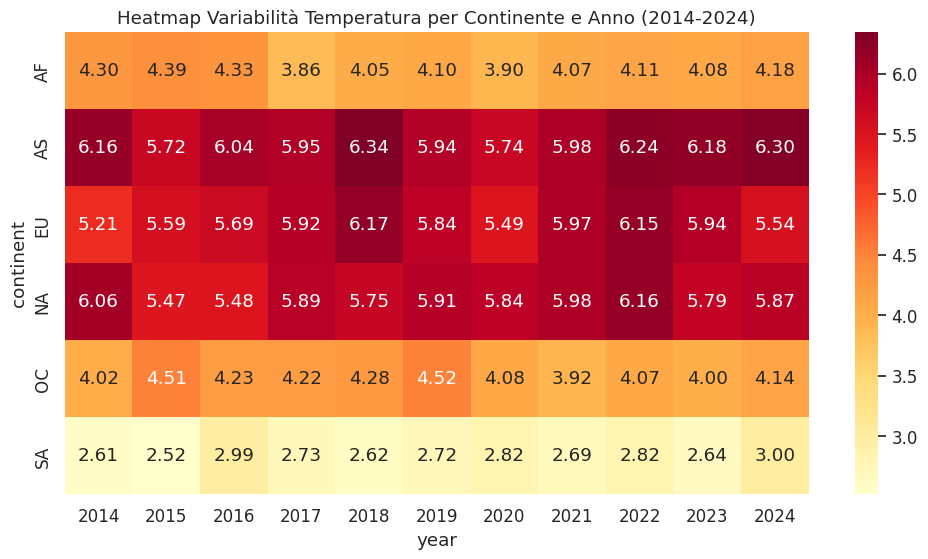

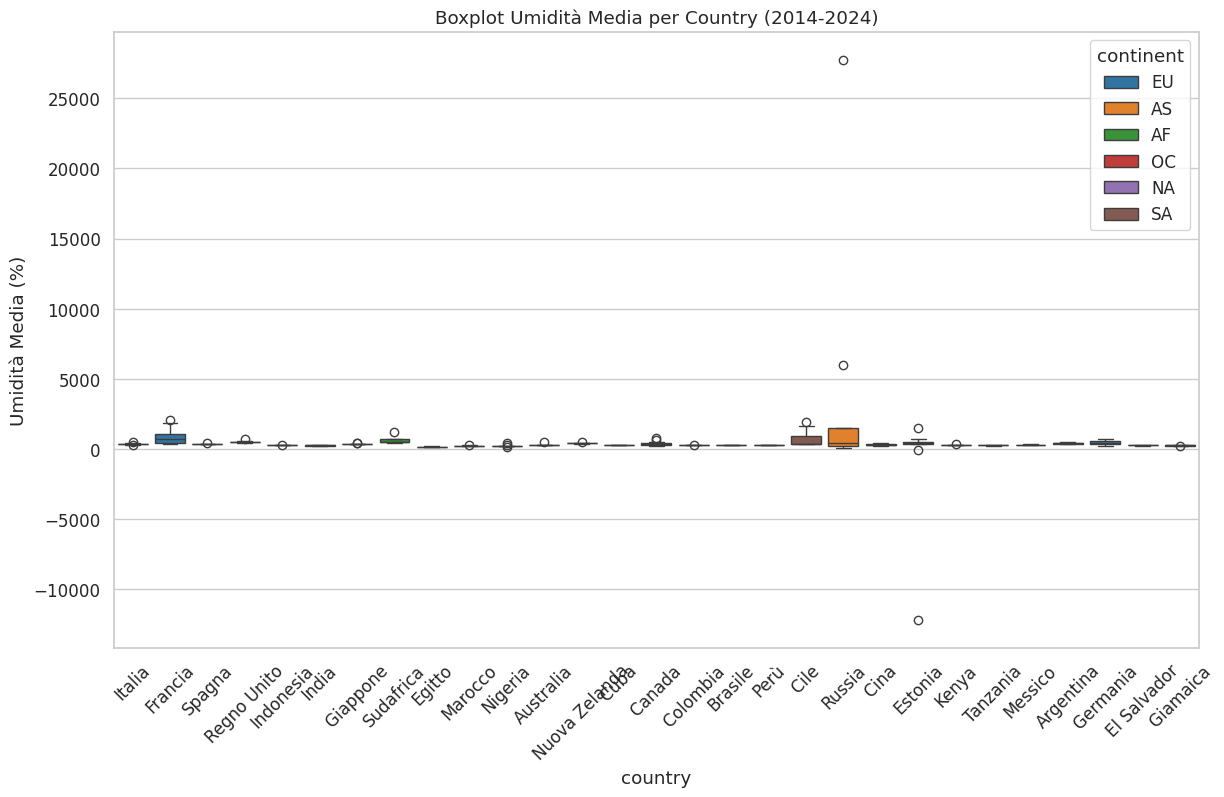

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-4906186020937676>, line 54
     51 plt.show()
     53 # --- Plotly: Scatter anomalie temp per country (size = giorni caldo >35°C) ---
---> 54 pdf_anomalie = anomalie.toPandas()  # assumi anomalie da codice precedente
     55 fig_scatter_anom = px.scatter(
     56     pdf_anomalie,
     57     x="year",
   (...)
     62     title="Anomalie Temperatura vs Baseline per Country (Size: Giorni >35°C)"
     63 )
     64 fig_scatter_anom.update_layout(height=600)

NameError: name 'anomalie' is not defined

In [0]:
# =============================================================================
# GRAFICI CON PLOTLY E SEABORN (per statistiche e top)
# =============================================================================

# Converti in Pandas per grafici (piccolo dataset → veloce)
pdf_stats_cont = stats_continent_year.toPandas()
pdf_stats_country = stats_country_year.toPandas()
pdf_top6_cont = top6_cont_temp.toPandas()
pdf_top10_country = top10_country_temp.toPandas()

# --- Plotly: Line trend media temp per continente ---
fig_line_cont = px.line(
    pdf_stats_cont,
    x="year",
    y="avg_temp_c",
    color="continent",
    markers=True,
    title="Trend Temperatura Media Annuale per Continente (2014-2024)",
    labels={"avg_temp_c": "Temp Media (°C)", "year": "Anno"}
)
fig_line_cont.update_layout(hovermode="x unified", height=600)
fig_line_cont.show()

# --- Seaborn: Heatmap variabilità temp per continente/anno ---
plt.figure(figsize=(12, 6))
pivot_var = pdf_stats_cont.pivot(index="continent", columns="year", values="variabilita_temp_c")
sns.heatmap(pivot_var, annot=True, cmap="YlOrRd", fmt=".2f")
plt.title("Heatmap Variabilità Temperatura per Continente e Anno (2014-2024)")
plt.show()

# --- Plotly: Bar top6 continenti per media temp ultimo anno ---
last_year = pdf_top6_cont["year"].max()
pdf_last_cont = pdf_top6_cont[pdf_top6_cont["year"] == last_year]
fig_bar_cont = px.bar(
    pdf_last_cont,
    x="continent",
    y="avg_temp_c",
    text="rank_temp",
    title=f"Top6 Continenti per Media Temp nell'Anno {last_year}"
)
fig_bar_cont.update_traces(textposition="outside")
fig_bar_cont.update_layout(height=500)
fig_bar_cont.show()

# --- Seaborn: Boxplot umidità per country (2014-2024) ---
plt.figure(figsize=(14, 8))
sns.boxplot(data=pdf_stats_country, x="country", y="avg_umidita_pct", hue="continent")
plt.title("Boxplot Umidità Media per Country (2014-2024)")
plt.xticks(rotation=45)
plt.ylabel("Umidità Media (%)")
plt.show()

# --- Plotly: Scatter anomalie temp per country (size = giorni caldo >35°C) ---
pdf_anomalie = anomalie.toPandas()  # assumi anomalie da codice precedente
fig_scatter_anom = px.scatter(
    pdf_anomalie,
    x="year",
    y="anomalia_temp_c",
    color="country",
    size="giorni_caldo_gt_35c",
    hover_data=["continent", "NAME"],
    title="Anomalie Temperatura vs Baseline per Country (Size: Giorni >35°C)"
)
fig_scatter_anom.update_layout(height=600)
fig_scatter_anom.show()

# --- Seaborn: Line trend giorni gelo per continente ---
pdf_gelo = cold_heat.groupBy("continent", "year").avg("giorni_gelo_lt_0c").toPandas()
plt.figure(figsize=(12, 6))
sns.lineplot(data=pdf_gelo, x="year", y="avg(giorni_gelo_lt_0c)", hue="continent", marker="o")
plt.title("Trend Giorni di Gelo (<0°C) per Continente (2014-2024)")
plt.ylabel("Media Giorni di Gelo")
plt.show()

# --- Plotly: Bar eventi estremi (fulmini, neve, grandine) per continente ultimo anno ---
pdf_events = events.groupBy("continent").sum("giorni_fulmini", "giorni_neve", "giorni_grandine").toPandas()
pdf_events_melt = pdf_events.melt(id_vars=["continent"], var_name="evento", value_name="giorni")
fig_bar_events = px.bar(
    pdf_events_melt,
    x="continent",
    y="giorni",
    color="evento",
    title="Eventi Estremi per Continente (2014-2024 Aggregato)"
)
fig_bar_events.update_layout(height=500)
fig_bar_events.show()

# --- Seaborn: Heatmap escursione temp per country/anno ---
pdf_esc = esc_wind.groupBy("country", "year").avg("avg_escursione_temp_c").toPandas()
plt.figure(figsize=(14, 8))
pivot_esc = pdf_esc.pivot(index="country", columns="year", values="avg(avg_escursione_temp_c)")
sns.heatmap(pivot_esc, annot=True, cmap="Oranges", fmt=".1f")
plt.title("Heatmap Escursione Termica Media per Country e Anno (2014-2024)")
plt.show()

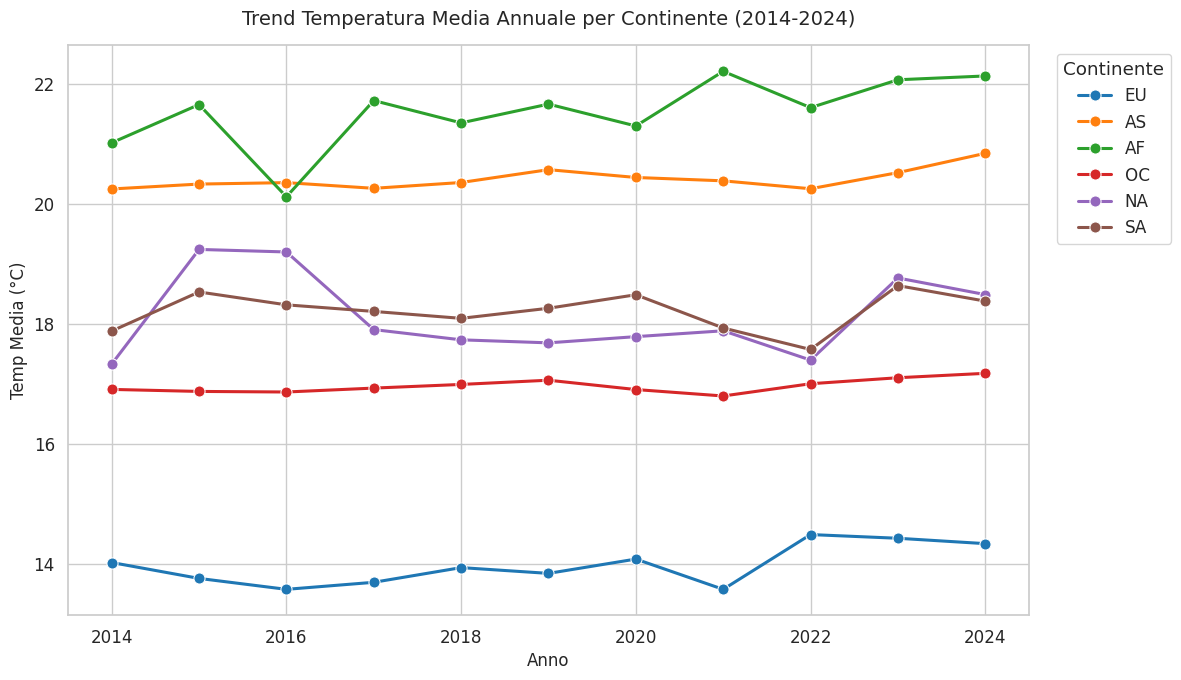

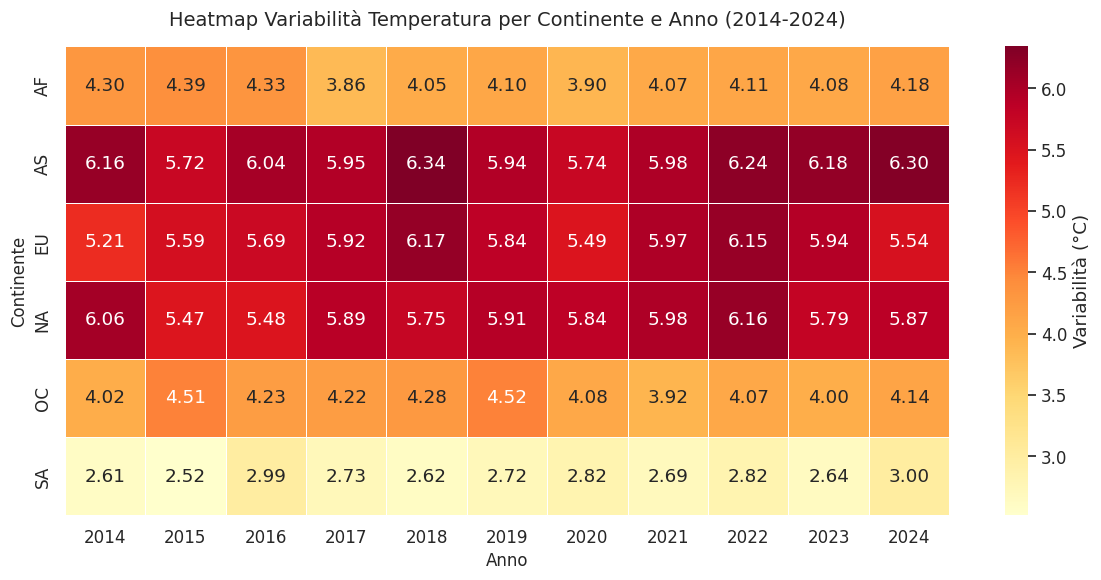

/home/spark-710369b3-e2c0-4495-af15-b7/.ipykernel/3443/command-5268839346383692-1460738872:68: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




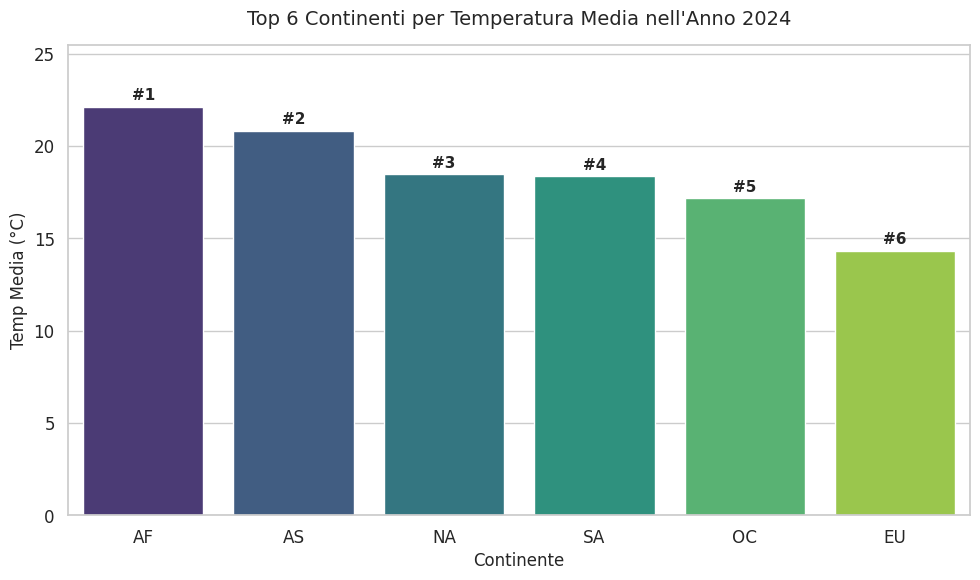

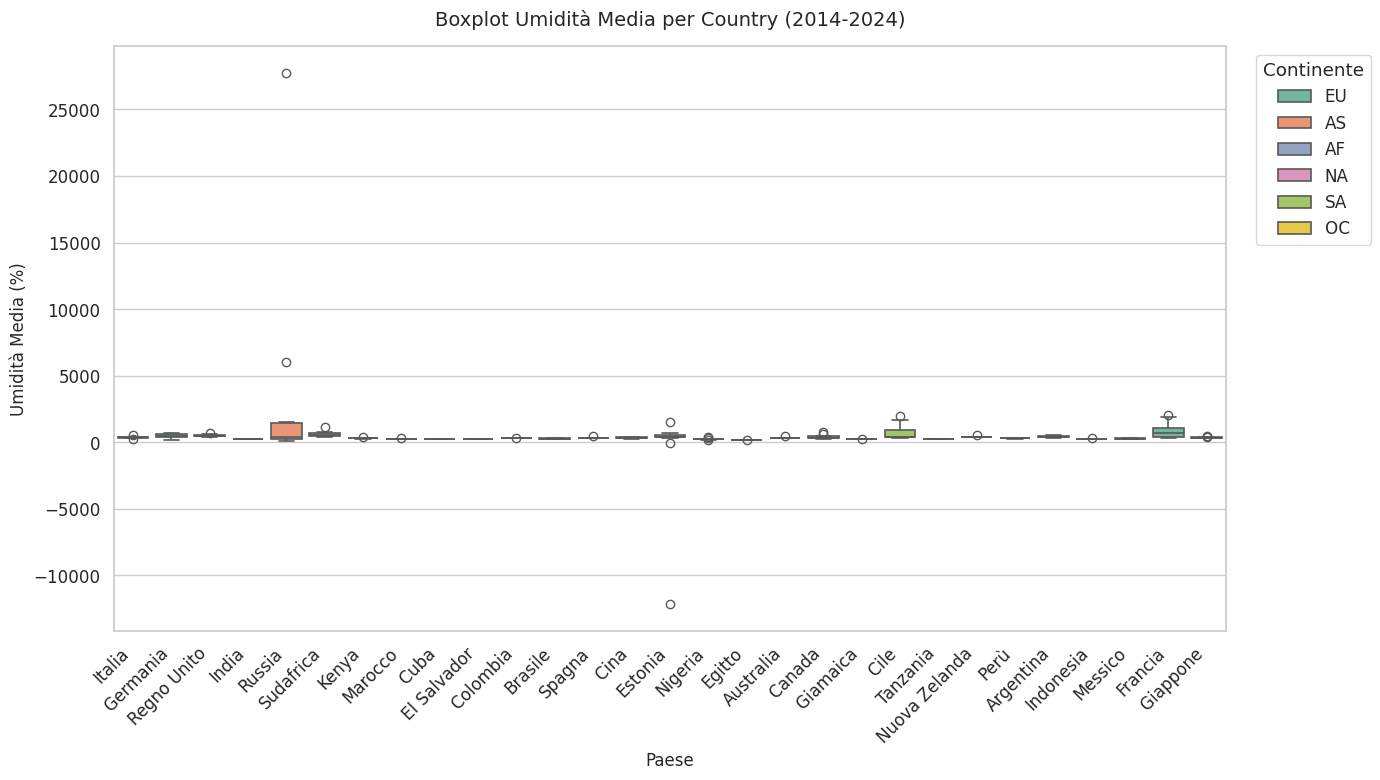

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-5268839346383692>, line 120
    113 plt.show()
    115 # =============================================================================
    116 # Le tabelle rimangono invariate (display in Databricks)
    117 # =============================================================================
    118 
    119 # Giorni gelo / caldo
--> 120 display(cold_heat)
    122 # Eventi estremi (da FRSHTT)
    123 display(events)

NameError: name 'cold_heat' is not defined

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Impostazioni globali per Seaborn (stile più pulito e leggibile)
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

# Converti in Pandas (dataset aggregati piccoli → ok)
pdf_stats_cont   = stats_continent_year.toPandas()
pdf_stats_country = df.groupBy("country", "year", "continent") \
                      .agg(F.avg("TEMP_c").alias("avg_temp_c"),
                           F.avg(F.when(F.col("TEMP_c") != 0, (F.col("DEWP") / F.col("TEMP_c")) * 100)).alias("avg_umidita_pct")) \
                      .toPandas()
pdf_top6_cont    = top6_cont_temp.toPandas()
pdf_top10_country = top10_country_temp.toPandas()

# =============================================================================
# 1. Trend temperatura media per continente (ex Plotly line → Seaborn lineplot)
# =============================================================================

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=pdf_stats_cont,
    x="year",
    y="avg_temp_c",
    hue="continent",
    marker="o",
    linewidth=2.2,
    markersize=8
)
plt.title("Trend Temperatura Media Annuale per Continente (2014-2024)", fontsize=14, pad=15)
plt.xlabel("Anno", fontsize=12)
plt.ylabel("Temp Media (°C)", fontsize=12)
plt.legend(title="Continente", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# =============================================================================
# 2. Heatmap variabilità temperatura per continente/anno (già Seaborn)
# =============================================================================

plt.figure(figsize=(12, 6))
pivot_var = pdf_stats_cont.pivot(index="continent", columns="year", values="variabilita_temp_c")
sns.heatmap(
    pivot_var,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={'label': 'Variabilità (°C)'}
)
plt.title("Heatmap Variabilità Temperatura per Continente e Anno (2014-2024)", fontsize=14, pad=15)
plt.xlabel("Anno", fontsize=12)
plt.ylabel("Continente", fontsize=12)
plt.tight_layout()
plt.show()

# =============================================================================
# 3. Bar top6 continenti per media temp ultimo anno (ex Plotly bar → Seaborn barplot)
# =============================================================================

pdf_last_cont = pdf_top6_cont[pdf_top6_cont["year"] == last_year].copy()
pdf_last_cont = pdf_last_cont.sort_values("avg_temp_c", ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=pdf_last_cont,
    x="continent",
    y="avg_temp_c",
    palette="viridis"
)

# Aggiungi etichette di rank sopra le barre
for i, row in pdf_last_cont.reset_index().iterrows():
    ax.text(
        i,
        row["avg_temp_c"] + 0.2,
        f"#{row['rank_temp']}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.title(f"Top 6 Continenti per Temperatura Media nell'Anno {last_year}", fontsize=14, pad=15)
plt.xlabel("Continente", fontsize=12)
plt.ylabel("Temp Media (°C)", fontsize=12)
plt.ylim(0, pdf_last_cont["avg_temp_c"].max() * 1.15)  # spazio per le etichette
plt.tight_layout()
plt.show()

# =============================================================================
# 4. Boxplot umidità per country (già Seaborn)
# =============================================================================

plt.figure(figsize=(14, 8))
sns.boxplot(
    data=pdf_stats_country,
    x="country",
    y="avg_umidita_pct",
    hue="continent",
    palette="Set2",
    linewidth=1.2
)
plt.title("Boxplot Umidità Media per Country (2014-2024)", fontsize=14, pad=15)
plt.xlabel("Paese", fontsize=12)
plt.ylabel("Umidità Media (%)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Continente", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# =============================================================================
# Le tabelle rimangono invariate (display in Databricks)
# =============================================================================

# Giorni gelo / caldo
display(cold_heat)

# Eventi estremi (da FRSHTT)
display(events)

# Escursione termica + vento
display(esc_wind)

# Anomalie vs baseline
display(anomalie)

print("Analisi completata. Tutte le visualizzazioni sono ora in Seaborn / Matplotlib.")

/home/spark-710369b3-e2c0-4495-af15-b7/.ipykernel/3443/command-5268839346383693-1397028779:30: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/home/spark-710369b3-e2c0-4495-af15-b7/.ipykernel/3443/command-5268839346383693-1397028779:30: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/home/spark-710369b3-e2c0-4495-af15-b7/.ipykernel/3443/command-5268839346383693-1397028779:30: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/home/spark-710369b3-e2c0-4495-af15-b7/.ipykernel/3443/command-5268839346383693-1397028779:30: FutureWarning:



Passing `palette` without assigning `hue` is de

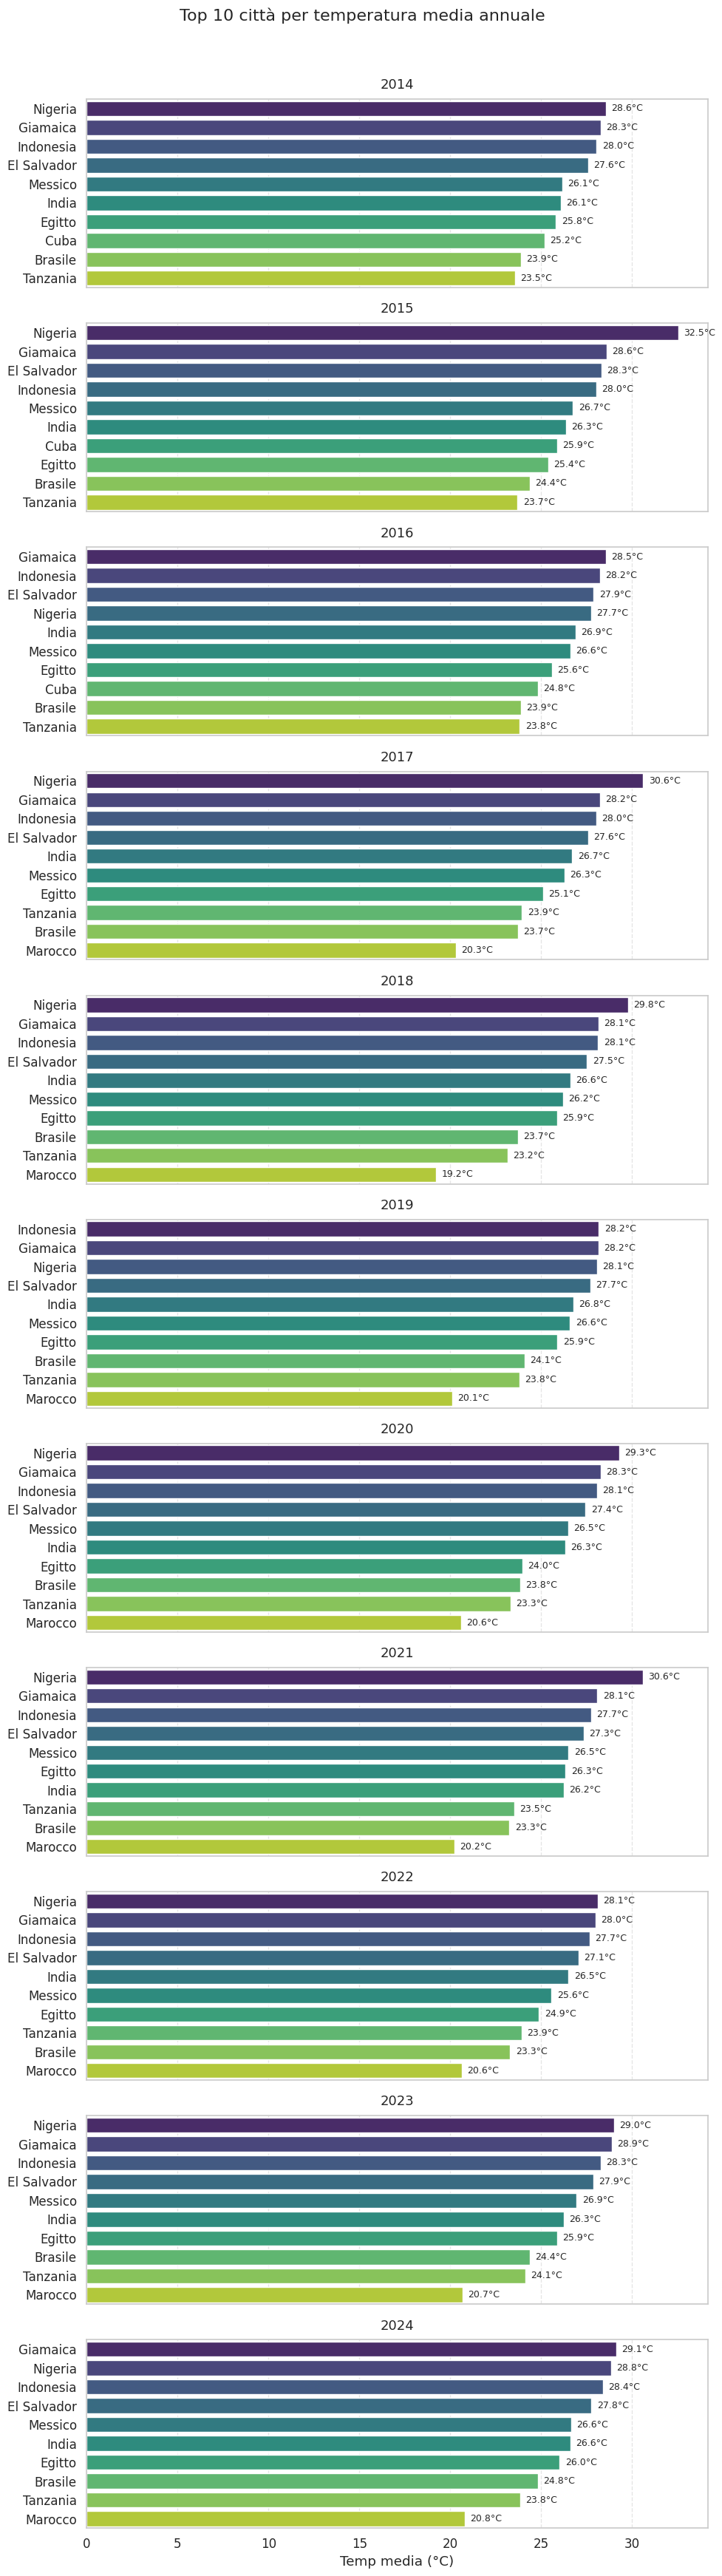

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Supponiamo di avere già un dataframe con colonne: year, city, avg_temp_c
# Esempio: df_agg = df.groupBy("year", "city").agg(F.avg("TEMP_c").alias("avg_temp_c"))

# Prendiamo solo gli ultimi 10-15 anni per non fare una figura eterna
df_plot = stats_country_year.filter(F.col("year") >= 2010).toPandas()

# Ordiniamo per anno e temperatura decrescente
df_plot = df_plot.sort_values(["year", "avg_temp_c"], ascending=[True, False])

# Prendiamo solo top 10 per ogni anno
top10_per_year = df_plot.groupby("year").head(10).reset_index(drop=True)

# Colori per differenziare un po' le barre
colors = sns.color_palette("viridis", len(top10_per_year["country"].unique()))

# Figura alta con tanti mini-grafici uno sotto l'altro
years = sorted(top10_per_year["year"].unique())
n_years = len(years)

fig, axes = plt.subplots(n_years, 1, figsize=(10, 3.2 * n_years), sharex=True)
fig.suptitle("Top 10 città per temperatura media annuale", fontsize=16, y=0.99)

for i, year in enumerate(years):
    df_year = top10_per_year[top10_per_year["year"] == year]
    
    sns.barplot(
        data=df_year,
        y="country",
        x="avg_temp_c",
        ax=axes[i],
        palette="viridis",
        orient="h"
    )
    
    axes[i].set_title(f"{year}", fontsize=13, pad=10)
    axes[i].set_xlabel("Temp media (°C)" if i == n_years-1 else "")
    axes[i].set_ylabel("")
    axes[i].grid(axis="x", linestyle="--", alpha=0.5)
    
    # Valore sulla barra
    for bar in axes[i].patches:
        width = bar.get_width()
        axes[i].text(
            width + 0.3,
            bar.get_y() + bar.get_height()/2,
            f"{width:.1f}°C",
            va="center",
            fontsize=9
        )

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()